<a href="https://colab.research.google.com/github/TaruniRavipudi/RavipudiTaruni_Projects_and_Labs/blob/main/Taruni_Module6_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
import random

In [4]:
# load the dataset

iris = load_iris()
data, labels = iris.data[:,0:2], iris.data[:,2]

num_samples = len(labels)  # size of our dataset

# shuffle the dataset
shuffle_order = np.random.permutation(num_samples)
data = data[shuffle_order, :]
labels = labels[shuffle_order]

In [5]:
def weighted_sum(x, w, b):
    return b + np.dot(w, x)

# set our paramters - weights and bias
w = [0.2, 0.6]
b = -0.3

# for example, let's use the first data point
X, y = data, labels

pred_y = [weighted_sum(x, w, b) for x in X]

# let's print out the first prediction
print("for x=[%0.2f, %0.2f], predicted = %0.2f, actual = %0.2f" % (X[0][0], X[0][1], pred_y[0], y[0]))

for x=[4.70, 3.20], predicted = 2.56, actual = 1.30


In [6]:
# sum squared error
def cost_function(y_pred, y_actual):
    return 0.5 * np.sum((y_actual-y_pred)**2)

error = cost_function(pred_y, y)
print(error)

313.5056


In [7]:
# normalizing the data
X = X / np.amax(X, axis=0)
y = y / np.amax(y, axis=0)

# randomly initializing w, b
w, b = [random.random(), random.random()], random.random()

# our function w*x + b
def F(X, w, b):
    return np.sum(w*X, axis=1) + b

# calculating error using cost function(Here we use Mean Squared Error)
y_pred = F(X, w, b)
init_cost = cost_function(y_pred, y)

print("initial parameters: w1=%0.3f, w2=%0.3f, b=%0.3f"%(w[0], w[1], b))
print("initial cost = %0.3f" % init_cost)

initial parameters: w1=0.784, w2=0.431, b=0.533
initial cost = 59.835


In [8]:
# implement partial derivatives of our parameters

def dJdw1(X, y, w, b):
    return -np.dot(X[:,0], y - F(X, w, b))

def dJdw2(X, y, w, b):
    return -np.dot(X[:,1], y - F(X, w, b))

def dJdb(X, y, w, b):
    return -np.sum(y - F(X, w, b))

In [9]:
# choose the learning rate parameter and number of iterations
lr = 0.001
n_iters = 2000

# run through gradient descent
errors = []
for i in range(n_iters):
    w[0] = w[0] - lr * dJdw1(X, y, w, b)
    w[1] = w[1] - lr * dJdw2(X, y, w, b)
    b = b - lr * dJdb(X, y, w, b)
    y_pred = F(X, w, b)
    j = cost_function(y_pred, y)
    errors.append(j)

Text(0.5, 0, 'iterations')

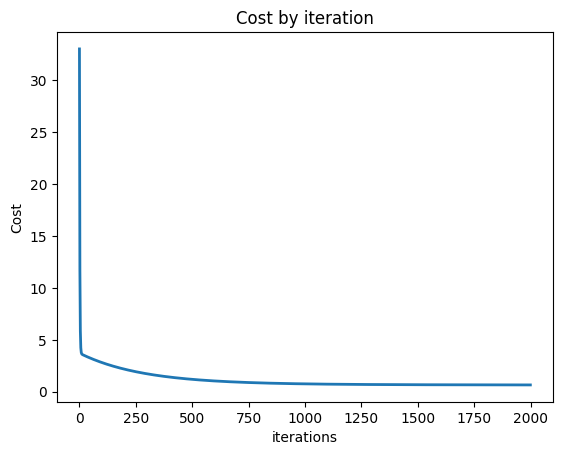

In [10]:
# plot the error
plt.plot(range(n_iters), errors, linewidth=2)
plt.title("Cost by iteration")
plt.ylabel("Cost")
plt.xlabel("iterations")

In [11]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [12]:
def weighted_sum(x, w, b):
    return b + np.dot(w, x)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# our parameters
w = [0.2, 0.6]
b = -0.3

X, y = data, labels

# get weighted sum like before
Z = [weighted_sum(x, w, b) for x in X]

# now transform the weighted sums with a sigmoid
y_pred = [sigmoid(z) for z in Z]

# evaluate error
error = cost_function(y_pred, y)
print(error)

829.3581552057612


In [13]:
W1 = np.random.randn(2, 3)
W2 = np.random.randn(3, 1)

print("W1=", W1)
print("W2=", W2)

W1= [[ 0.33635314 -0.46645143  0.01570783]
 [ 0.17016129 -0.31169118 -0.64342498]]
W2= [[ 0.58108706]
 [-2.03199692]
 [ 0.55298505]]


In [14]:

X, y = data, labels

# first layer weighted sum z
z = np.dot(X, W1)

# project z through non-linear sigmoid
z = sigmoid(z)

# do another dot product at end (sigmoid is omitted)
y_pred = np.dot(z, W2)

# what is our cost
error = cost_function(y_pred, y)

print('predicted %0.2f for example 0, actual %0.2f, total cost %0.2f'%(pred_y[0], y[0], error))

predicted 2.56 for example 0, actual 1.30, total cost 150120.70


In [15]:
class Neural_Network(object):
    def __init__(self, n0, n1, n2):
        self.n0 = n0
        self.n1 = n1
        self.n2 = n2

        # initialize weights
        self.W1 = np.random.randn(self.n0, self.n1)
        self.W2 = np.random.randn(self.n1 ,self.n2)

    def predict(self, x):
        z = np.dot(x, self.W1)
        z = sigmoid(z)
        y = np.dot(z, self.W2)
        return y


In [16]:
# instantiate a neural network with 2 input neurons, 3 hidden neurons, and 1 output neuron using above class

net = Neural_Network(2, 3, 1)

In [17]:
X, y = data, labels
y_pred = net.predict(X)
error = cost_function(y_pred, y)

print('predicted %0.2f for example 0, actual %0.2f, total cost %0.2f'%(pred_y[0], y[0], error))

predicted 2.56 for example 0, actual 1.30, total cost 81347.57


In [18]:
def get_gradient(net, X, y):
    w_delta = 1e-8

    # get the current value of the loss, wherever the parameters are
    y_pred_current = net.predict(X)
    error_current = cost_function(y_pred_current, y)

    # grab the current weights and copy them (so we can restore them after modification)
    dw1, dw2 = np.zeros((net.n0, net.n1)), np.zeros((net.n1, net.n2))
    W1, W2 = np.copy(net.W1), np.copy(net.W2)

    # Calculate gradient for the first layer
    for i in range(net.n0):
        for j in range(net.n1):
            net.W1 = np.copy(W1)
            net.W1[i][j] += w_delta
            y_pred = net.predict(X)
            error = cost_function(y_pred, y)
            dw1[i][j] = (error - error_current) / w_delta

    # Calculate gradient for the second layer
    for i in range(net.n1):
        for j in range(net.n2):
            net.W2 = np.copy(W2)
            net.W2[i][j] += w_delta
            y_pred = net.predict(X)
            error = cost_function(y_pred, y)
            dw2[i][j] = (error - error_current) / w_delta

    # restore the original weights
    net.W1, net.W2 = np.copy(W1), np.copy(W2)

    return dw1, dw2

In [19]:
# load the data and labels
X, y = data, labels.reshape((len(labels),1))

# it's always a good idea to normalize the data between 0 and 1
X = X/np.amax(X, axis=0)
y = y/np.amax(y, axis=0)

# create a 2x3x1 neural net
net = Neural_Network(2, 3, 1)

# what is the current cost?
y_orig = net.predict(X)
init_cost = cost_function(y_orig, y)
print("initial cost = %0.3f" % init_cost)

# Set the learning rate, and how many epochs (updates) to try
n_epochs = 2000
learning_rate = 0.01

# for each epoch, calculate the gradient, then subtract it from the parameters, and save the cost
errors = []
for i in range(n_epochs):
    dw1, dw2 = get_gradient(net, X, y)
    net.W1 = net.W1 - learning_rate * dw1
    net.W2 = net.W2 - learning_rate * dw2
    y_pred = net.predict(X)
    error = cost_function(y_pred, y)
    errors.append(error)


initial cost = 354.364


Text(0, 0.5, 'Error')

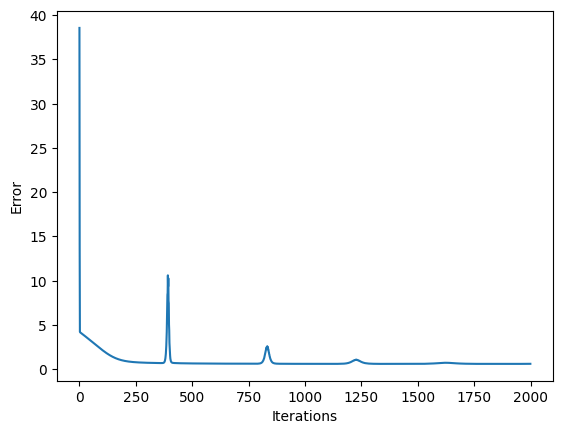

In [20]:
# plotting iterations vs error
plt.plot(range(0, len(errors)), errors)
plt.xlabel('Iterations')
plt.ylabel('Error')

In [21]:
def tanh(z):
    return np.tanh(z)

In [22]:
def relu(x):
    return np.maximum(0, x)

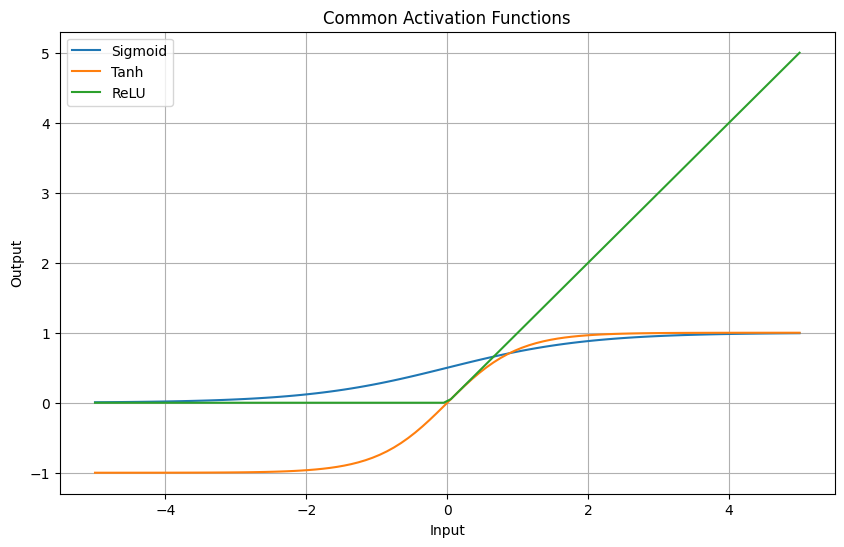

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(x):
    return np.maximum(0, x)

x_vals = np.linspace(-5, 5, 100)

plt.figure(figsize=(10, 6))

plt.plot(x_vals, sigmoid(x_vals), label='Sigmoid')
plt.plot(x_vals, tanh(x_vals), label='Tanh')
plt.plot(x_vals, relu(x_vals), label='ReLU')

plt.title('Common Activation Functions')
plt.xlabel('Input')
plt.ylabel('Output')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
def mean_absolute_error(y_pred, y_actual):
    return np.sum(np.abs(y_actual - y_pred)) / len(y_actual)

In [25]:
def hinge_loss(y_pred, y_actual):
    return np.mean(np.maximum(0, 1 - y_actual * y_pred))

In [26]:
import numpy as np
from sklearn.datasets import load_iris

# Load and shuffle the dataset
iris = load_iris()
data, labels = iris.data[:,0:2], iris.data[:,2]

num_samples = len(labels)  # size of our dataset

# shuffle the dataset
shuffle_order = np.random.permutation(num_samples)
data = data[shuffle_order, :]
labels = labels[shuffle_order]

# Now data and labels are defined. Assign to X, y for consistent variable names.
X, y = data, labels.reshape((len(labels),1))

# it's always a good idea to normalize the data between 0 and 1
X = X/np.amax(X, axis=0)
y = y/np.amax(y, axis=0)

# Define the sigmoid function
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Define the Neural_Network class
class Neural_Network(object):
    def __init__(self, n0, n1, n2):
        self.n0 = n0
        self.n1 = n1
        self.n2 = n2

        # initialize weights
        self.W1 = np.random.randn(self.n0, self.n1)
        self.W2 = np.random.randn(self.n1 ,self.n2)

    def predict(self, x):
        z = np.dot(x, self.W1)
        z = sigmoid(z)
        y = np.dot(z, self.W2)
        return y

def cost_function(y_pred, y_actual):
    return 0.5 * np.sum((y_actual-y_pred)**2)

# create a 2x3x1 neural net
net = Neural_Network(2, 3, 1)

# what is the current cost?
y_orig = net.predict(X)
init_cost = cost_function(y_orig, y)

# Define get_gradient
def get_gradient(net, X, y):
    w_delta = 1e-8

    # get the current value of the loss, wherever the parameters are
    y_pred_current = net.predict(X)
    error_current = cost_function(y_pred_current, y)

    # grab the current weights and copy them (so we can restore them after modification)
    dw1, dw2 = np.zeros((net.n0, net.n1)), np.zeros((net.n1, net.n2))
    W1, W2 = np.copy(net.W1), np.copy(net.W2)

    # Calculate gradient for the first layer
    for i in range(net.n0):
        for j in range(net.n1):
            net.W1 = np.copy(W1)
            net.W1[i][j] += w_delta
            y_pred = net.predict(X)
            error = cost_function(y_pred, y)
            dw1[i][j] = (error - error_current) / w_delta

    # Calculate gradient for the second layer
    for i in range(net.n1):
        for j in range(net.n2):
            net.W2 = np.copy(W2)
            net.W2[i][j] += w_delta
            y_pred = net.predict(X)
            error = cost_function(y_pred, y)
            dw2[i][j] = (error - error_current) / w_delta

    # restore the original weights
    net.W1, net.W2 = np.copy(W1), np.copy(W2)

    return dw1, dw2

# Set the learning rate, and how many epochs (updates) to try
n_epochs = 2000
learning_rate = 0.01

# for each epoch, calculate the gradient, then subtract it from the parameters, and save the cost
for i in range(n_epochs):
    dw1, dw2 = get_gradient(net, X, y)
    net.W1 = net.W1 - learning_rate * dw1
    net.W2 = net.W2 - learning_rate * dw2
    y_pred = net.predict(X)

# Define mean_absolute_error (assuming it's defined elsewhere or explicitly here if needed)
def mean_absolute_error(y_pred, y_actual):
    return np.sum(np.abs(y_actual - y_pred)) / len(y_actual)

# Now y_pred and y are defined for the final calculation
mae_error = mean_absolute_error(y_pred, y)
print("Mean Absolute Error: %0.3f" % mae_error)

Mean Absolute Error: 0.072


In [27]:
y_actual_hinge = np.array([1, 1, -1, -1, 1, -1])
y_pred_hinge = np.array([0.8, 0.2, -0.6, 0.1, 0.9, -0.9])

hinge_l = hinge_loss(y_pred_hinge, y_actual_hinge)
print("Hinge Loss (example): %0.3f" % hinge_l)

Hinge Loss (example): 0.450


In [29]:
#Exercise 1: Experiment with Activation Functions
def sigmoid(z):
    return 1/(1+np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

class Neural_Network(object):
    def __init__(self, n0, n1, n2, activation='sigmoid'):
        self.n0 = n0
        self.n1 = n1
        self.n2 = n2

        self.W1 = np.random.randn(n0, n1)
        self.W2 = np.random.randn(n1, n2)

        self.activation = activation

    def activate(self, z):
        if self.activation == 'sigmoid':
            return sigmoid(z)
        elif self.activation == 'tanh':
            return tanh(z)
        elif self.activation == 'relu':
            return relu(z)

    def predict(self, x):
        z = np.dot(x, self.W1)
        z = self.activate(z)
        y = np.dot(z, self.W2)
        return y

In [33]:
def train_network(activation, X, y, epochs=500, learning_rate=0.01):

    net = Neural_Network(2, 3, 1, activation)

    errors = []

    for i in range(epochs):

        dw1, dw2 = get_gradient(net, X, y)

        net.W1 -= learning_rate * dw1
        net.W2 -= learning_rate * dw2

        y_pred = net.predict(X)
        error = cost_function(y_pred, y)
        errors.append(error)

    return errors

In [34]:
errors_sigmoid = train_network('sigmoid', X, y)
errors_tanh = train_network('tanh', X, y)
errors_relu = train_network('relu', X, y)

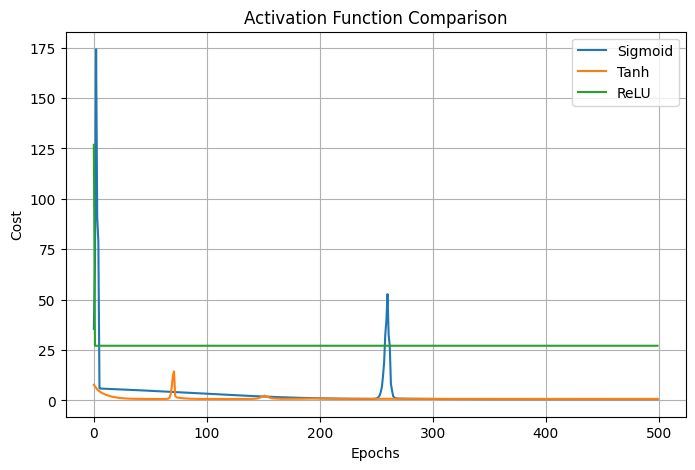

In [35]:
plt.figure(figsize=(8,5))

plt.plot(errors_sigmoid, label='Sigmoid')
plt.plot(errors_tanh, label='Tanh')
plt.plot(errors_relu, label='ReLU')

plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Activation Function Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [36]:
#Exercise 2: Implement a New Loss Function
def mean_absolute_error(y_pred, y_actual):
    return np.mean(np.abs(y_actual-y_pred))

In [37]:
# sum squared error
def cost_function(y_pred, y_actual):
    return 0.5 * np.sum((y_actual-y_pred)**2)

error = mean_absolute_error(pred_y, y)
print(error)

2.1584289855072467


In [38]:
def binary_cross_entropy(y_pred,y_true):
    epsilon = 1e-10
    y_pred = np.clip(y_pred,epsilon,1-epsilon)
    return -np.mean(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))

In [39]:
error = binary_cross_entropy(y_pred,y)

/tmp/ipykernel_2577/671396262.py:3: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


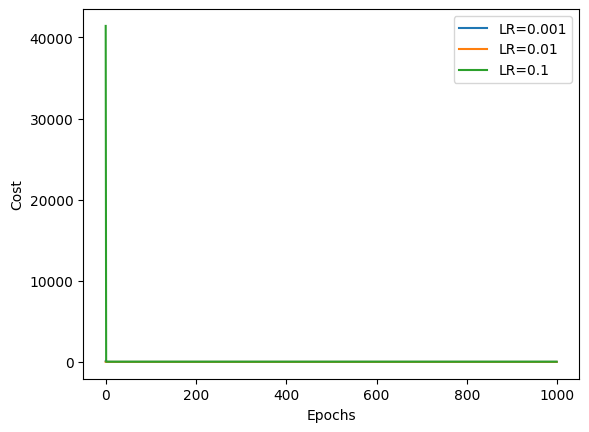

In [40]:
#Exercise 3: Hyperparameter Tuning
learning_rates = [0.001,0.01,0.1]

for lr in learning_rates:

    net = Neural_Network(2,3,1)
    errors=[]

    for i in range(1000):

        dw1,dw2 = get_gradient(net,X,y)

        net.W1 -= lr*dw1
        net.W2 -= lr*dw2

        y_pred = net.predict(X)
        errors.append(cost_function(y_pred,y))

    plt.plot(errors,label=f'LR={lr}')

plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.legend()
plt.show()

In [41]:
epochs = [500,1000,2000]

for e in epochs:
    print(e)

500
1000
2000


In [42]:
#Exercise 4: Add Bias to Hidden Layer
class Neural_Network(object):

    def __init__(self,n0,n1,n2):

        self.W1=np.random.randn(n0,n1)
        self.W2=np.random.randn(n1,n2)

        self.b1=np.random.randn(n1)
        self.b2=np.random.randn(n2)

    def predict(self,x):

        z=np.dot(x,self.W1)+self.b1
        z=sigmoid(z)

        y=np.dot(z,self.W2)+self.b2

        return y

In [43]:
#Exercise 5: Dying ReLU Problem
def leaky_relu(x):
    return np.where(x>0,x,0.01*x)

In [44]:
def elu(x,alpha=1):
    return np.where(x>0,x,alpha*(np.exp(x)-1))